In [ ]:
%pip install anthropic python-dotenv

In [3]:
from dotenv import load_dotenv
load_dotenv()

from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-6"


In [4]:
message = client.messages.create(
    model="claude-sonnet-4-6", 
    max_tokens=1000,
    messages=[
        {
            "role": "user",
            "content": "What is quantum computing? Answer in one sentence"
        }
    ]
)


Print  the output here

In [ ]:

message.content[0].text

Create a Builder Helper Functions

In [6]:
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

def chat(messages, system =None, temperature =0.0):
    params = {
        "model": model,
        "max_tokens":1000,
        "messages":messages,
        "temperature":temperature         
    }

    if system :
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

Putting It All Together 

In [ ]:
# Start with an empty message list
messages = []

# Add the initial user question
add_user_message(messages, "Define quantum computing in one sentence")

# Get Claude's response
answer = chat(messages)

# Add Claude's response to the conversation history
add_assistant_message(messages, answer)

# Add a follow-up question
add_user_message(messages, "Write another sentence")

# Get the follow-up response with full context
final_answer = chat(messages)
print(final_answer)

#### 1. Chat Bot Exercise 🧠

Make a chat bot using the three helper functions we just put together.

1. Prompt the user to enter some input using the built-in "input" function
2. Add it to a list of messages
3. Call the API
4. Add generated text to the list of messages
5. Print the generated text
6. Repeat from

In [ ]:
messages  =[]
while True:
  user_input = input(">")
  print(">",user_input)

  add_user_message(messages,user_input)
  answer  = chat(messages)
  add_assistant_message(messages,answer)

  print("---")
  print(answer)
  print("---")
  

#### 2. Chat Bot Exercise 🧠


Math Tutor Specialist
• Responses should:
• Initially, only give the student hints
• Patiently walk the student through a solution
• Show solutions for similar problems
• Responses should not:
• Immediately give a direct answer
• Tell the student to use a calculator

### What is System prompt 

System prompts provide claude guidance on how to respond. Claude will try the same way someone in the  specified role would respond. 


In [ ]:
messages = []
add_user_message(messages,"How do I solve 5x+3=2 for x?")

system = """
    You are a patient math tutor. Do not directly answer a student's questions. 
    Guide them to a solution step by step
     """


answer = chat(messages,system)
answer

#### 3.Exercise 🧠

##### Write a Python function that checks a string for duplicate characters. 


In [ ]:
from itertools import chain
messages =[]
add_user_message(messages,"Write a Python function that checks a string for duplicate characters. ")
answer  = chat(messages, system="You are a Python engineer who writes very concise code")
answer

Temperture 

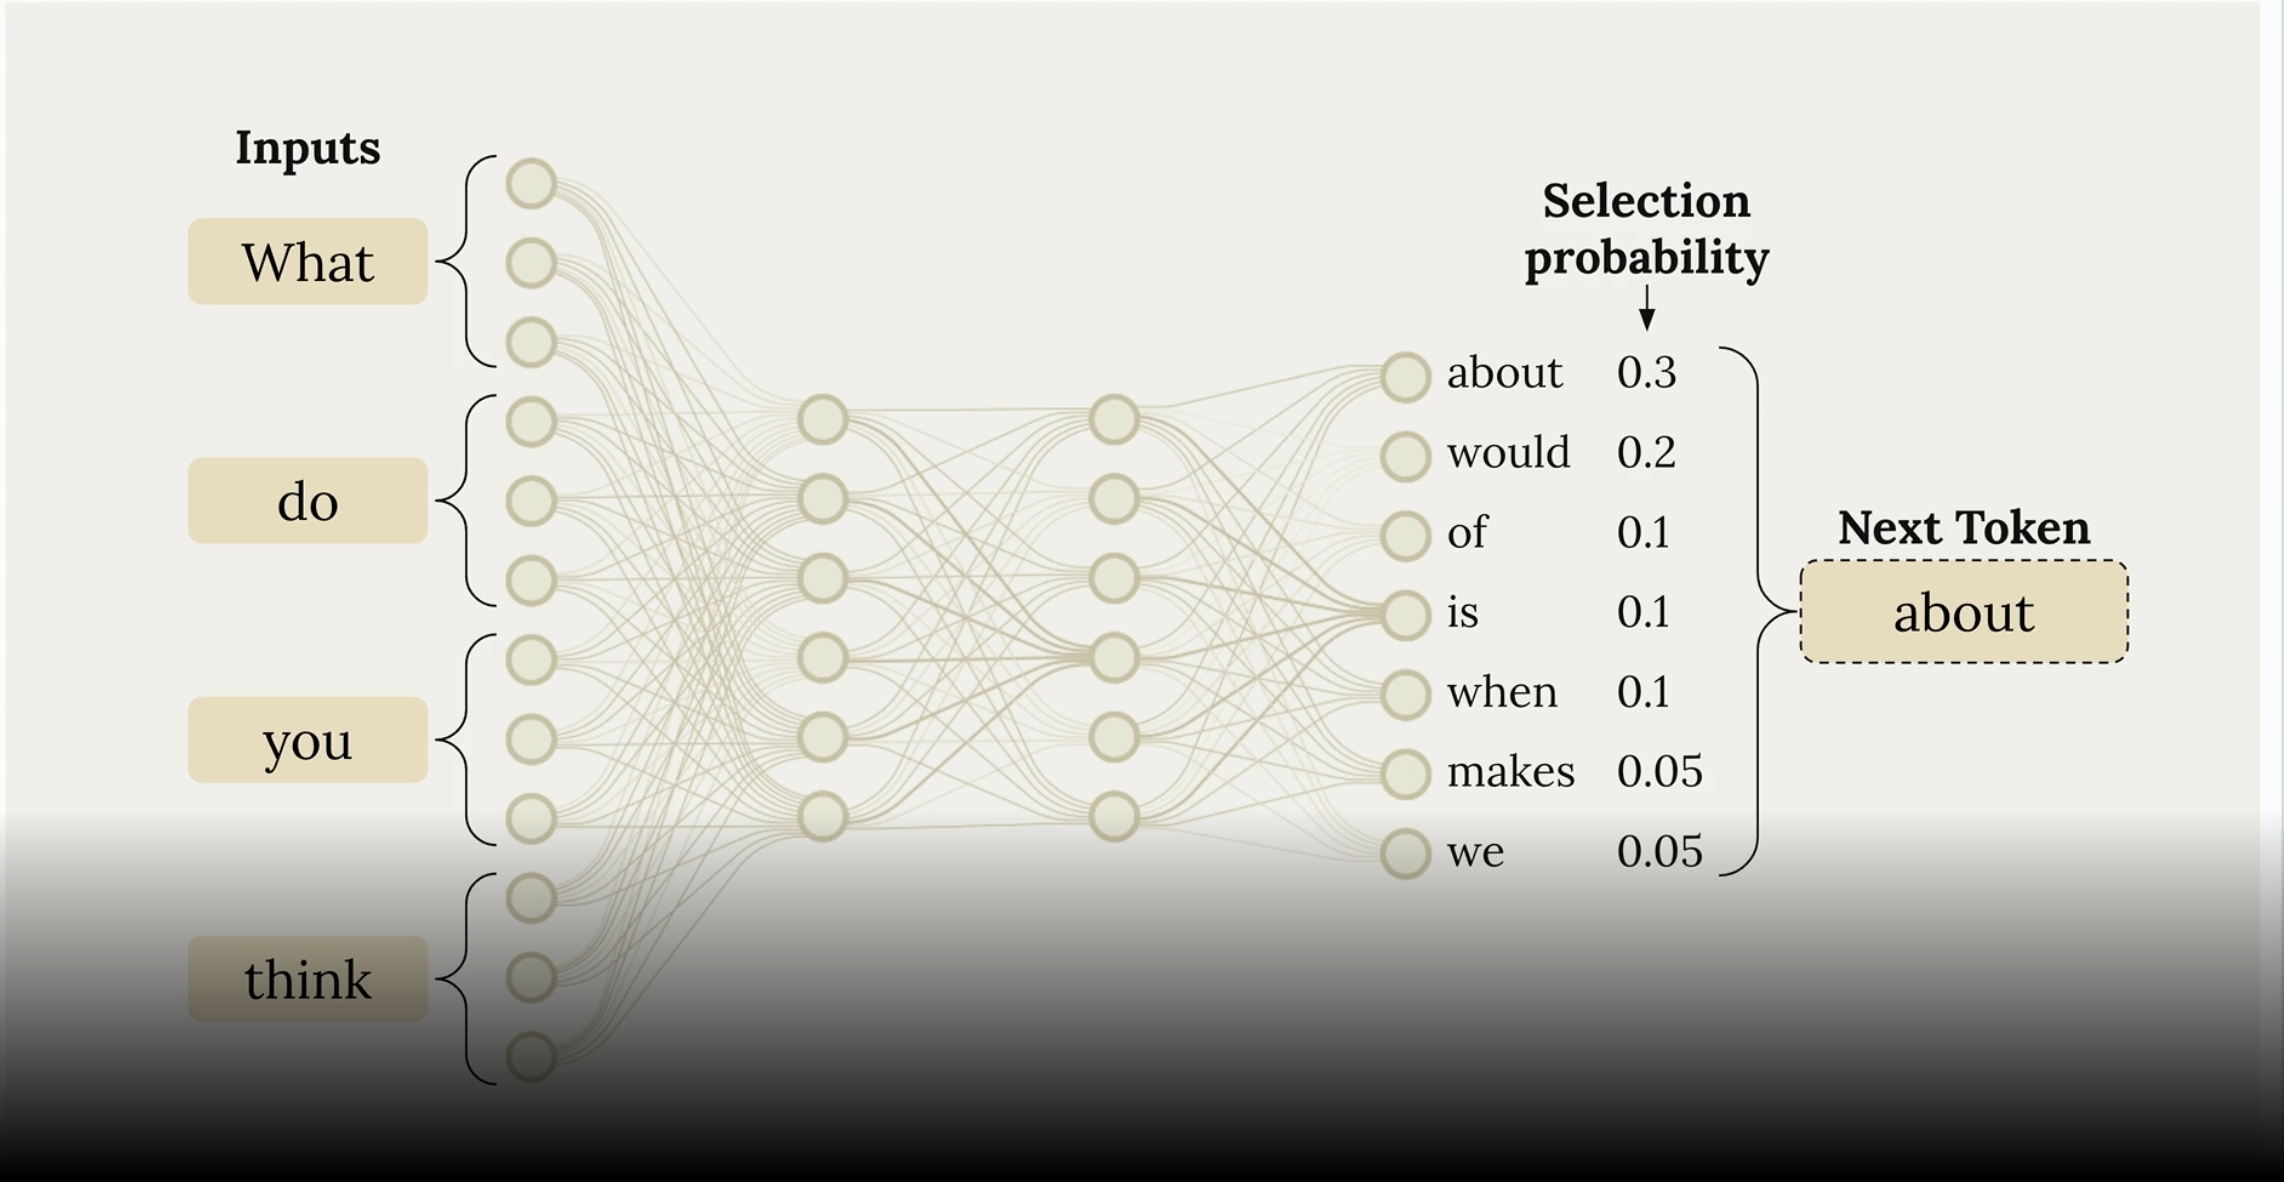

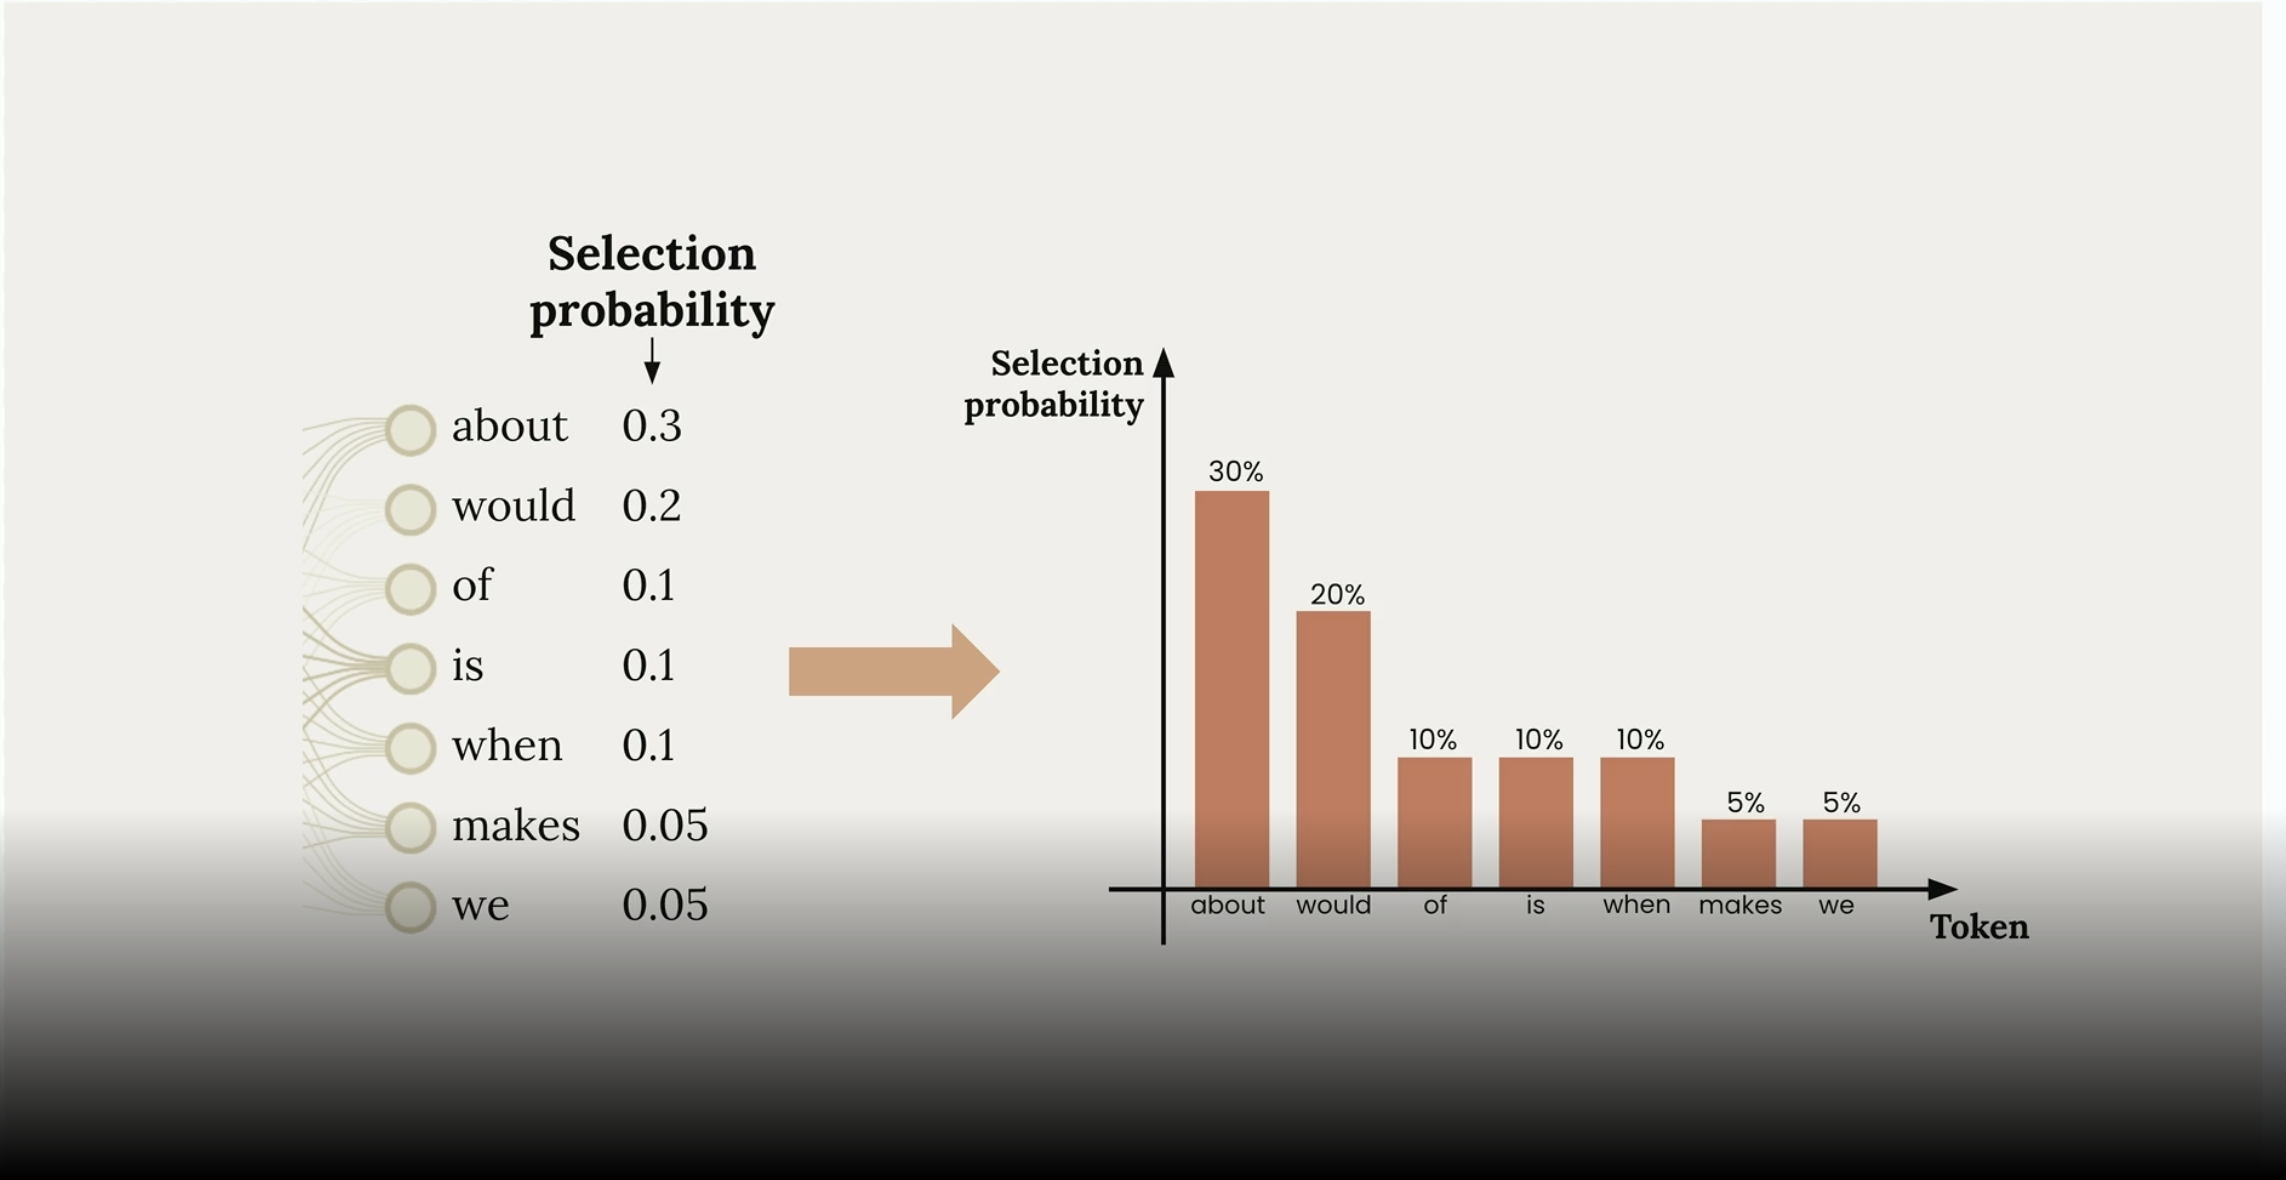

Temperature  is a probability  which controll the probability of the output. If the probability is low then the output is more deterministic  and if the temperatuer is high then the output is more random. 

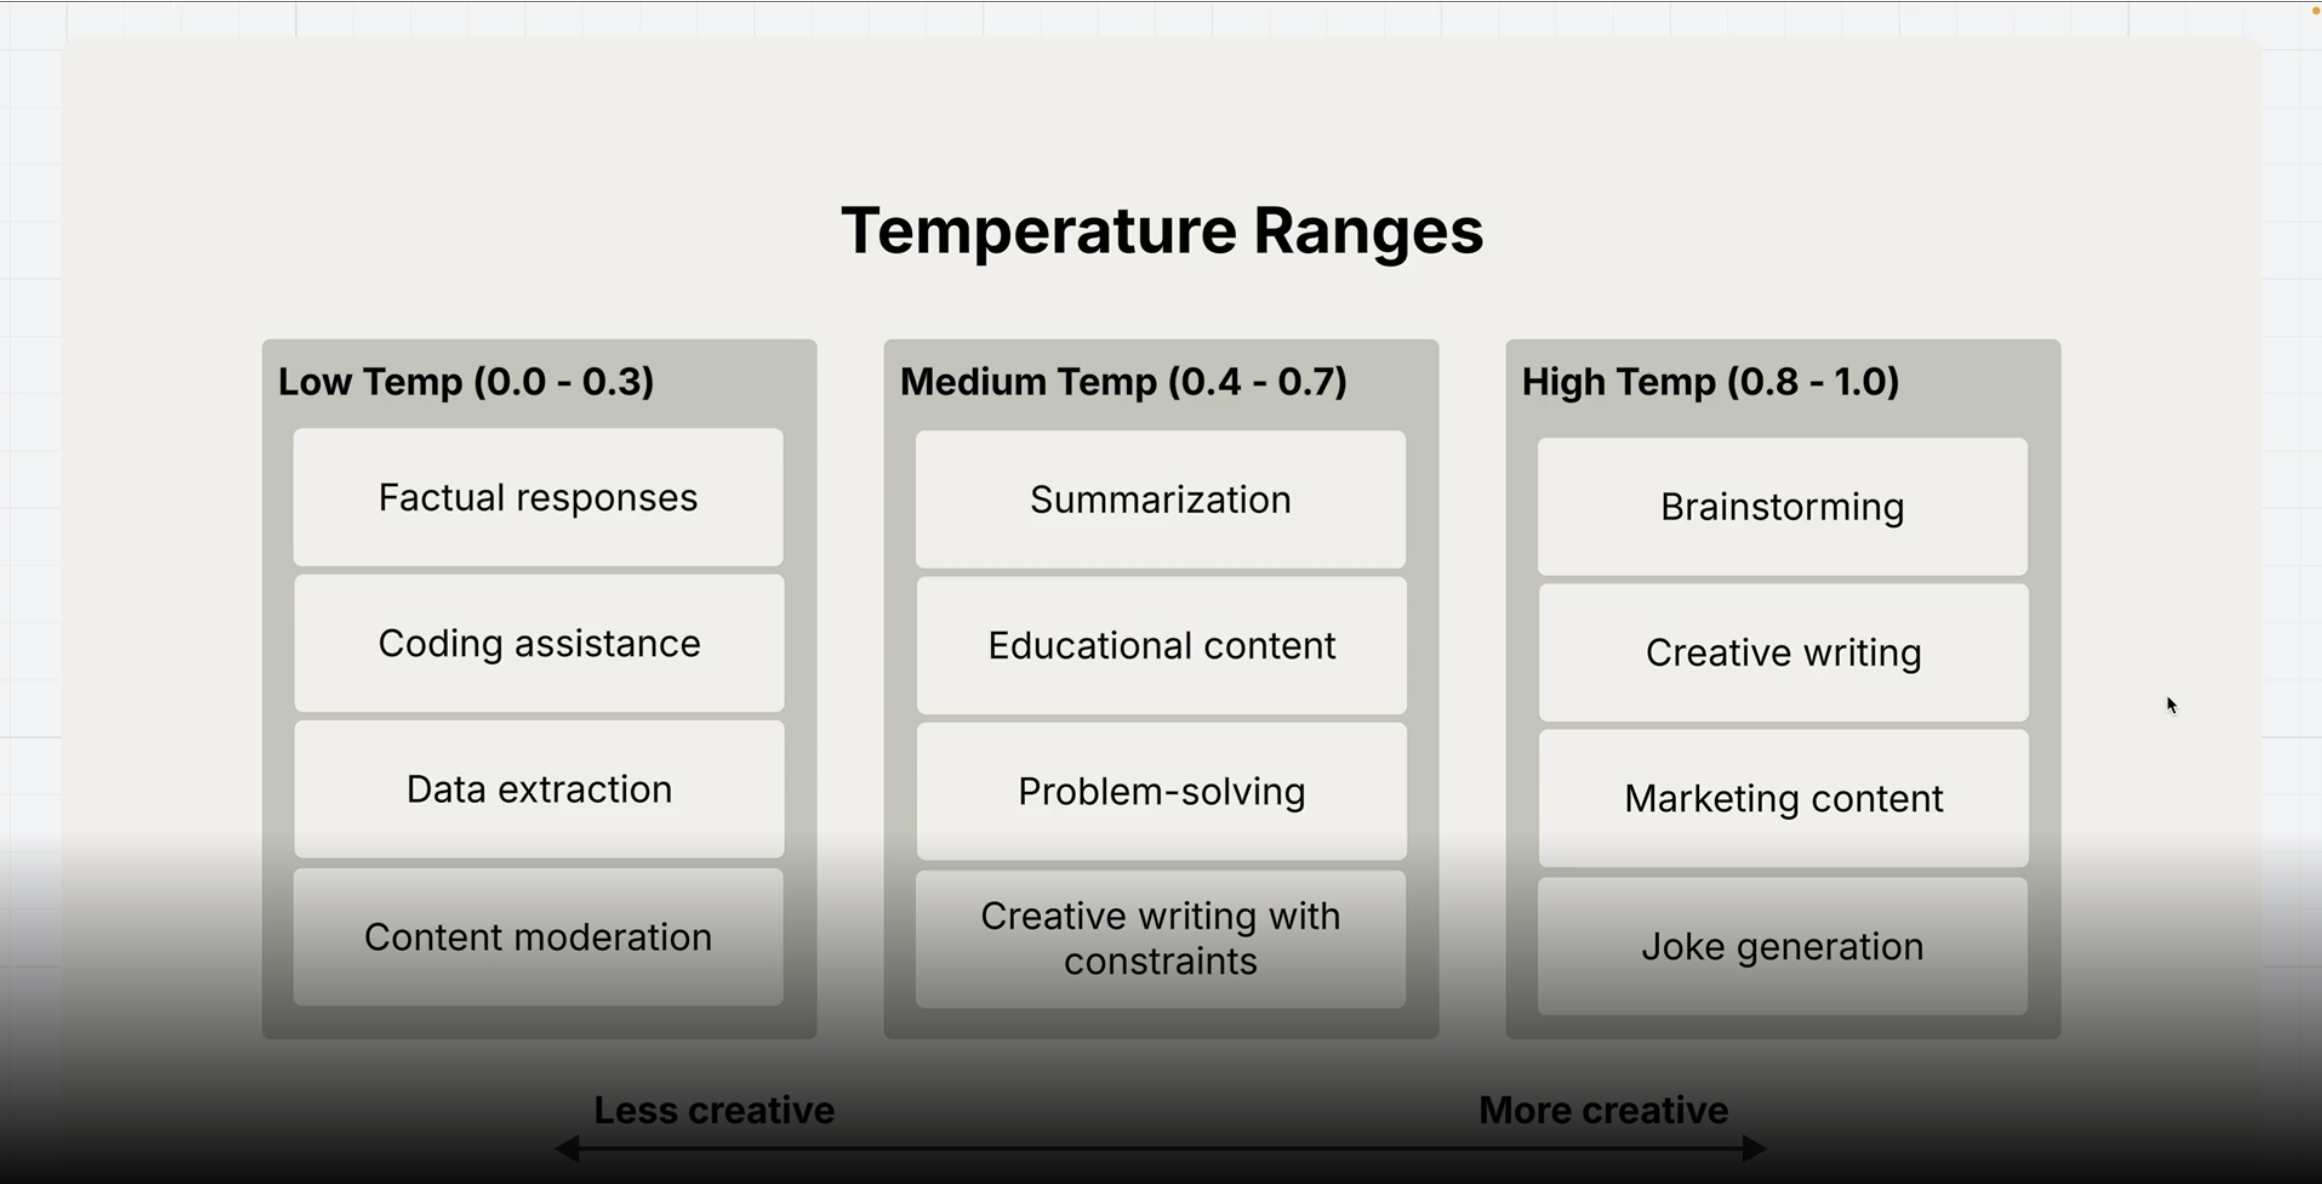

In [10]:
messages =[]
add_user_message(messages,"Generate a one sentence movie idea")
answer = chat(messages,temperature=1)
answer

"Here's a movie idea:\n\n**A retired forensic linguist is forced out of hiding when she realizes the anonymous ransom notes in a high-profile kidnapping case were written by someone who learned language exclusively from her own published books."